# Low-N Protein Engineering (Simulation) — ESM + BO on DMS pool

- Round-0: use 96 labeled variants
- Candidates: remaining rows from DMS dataset (simulation mode)
- Surrogate: GP (good for Low-N);
- Acquisition: Expected Improvement (EI) + Hamming-diverse picker

Setup & Config

In [44]:
import os, sys, math, random, itertools, time
from dataclasses import dataclass
from typing import List, Tuple, Iterable, Optional
from scipy.stats import spearmanr
from itertools import combinations

import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

from scipy.stats import norm
from tqdm.auto import tqdm

In [45]:
# -----------------------
# Repro & progress config
# -----------------------
RANDOM_SEED = 1337
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
SHOW_PROGRESS = True

# -----------------------
# User-configurable knobs
# -----------------------
# ESM model + device
MODEL_FAMILY = "esm1v"     # "esm1v" (match predict.py) or "esm2"
ESM_DEVICE   = "cuda"      # "cuda" or "cpu" (use "cpu" if your CUDA env isn't ready)

# Surrogate + features
PCA_DIM    = 32            # smaller dims are fine for 96 points
USE_GP     = True          # True: Gaussian Process; False: Simple Ridge ensemble (scales better)

# BO / candidate selection
BATCH_SIZE = 24            # propose 24 per round
XI         = 0.01          # EI exploration param
MIN_HD     = 2             # min Hamming distance among chosen
AA_ALPHABET = list("ACDEFGHIKLMNPQRSTVWY")

# Low-N simulation split
LOW_N = 96                 # seed size (Round-0)
CANDIDATE_POOL_SIZE = None # None = use all remaining DMS; or set e.g. 20000 for speed

# Files
REF_PATH = "../data/ref_gfp.csv"
DMS_PATH = "../data/dms_le2.csv" # for <= 2 mutation or use dms_all.csv for all mutation
RESULTS_DIR = "../results"

Data Classes & Utils

In [46]:
@dataclass
class LabeledSeq:
    seq: str
    fitness: float

@dataclass
class Proposal:
    seq: str
    mu: float
    sigma: float
    ei: float

def hamming(s1: str, s2: str) -> int:
    assert len(s1) == len(s2), "Sequences must have same length"
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))

def mean_pairwise_hamming(seqs):
    if len(seqs) < 2: return 0.0
    def ham(a,b): return sum(c1!=c2 for c1,c2 in zip(a,b))
    return float(np.mean([ham(a,b) for a,b in combinations(seqs,2)]))

def y_of(seqs, truth_map):  # returns np.array of true fitness
    return np.array([truth_map.get(s, np.nan) for s in seqs], dtype=float)

def topk_true_in_selected(selected, pool, truth_map, k):
    # “selection-based” hit@k: how many of your selected are in the true top-k of the current pool
    pool_sorted = sorted(pool, key=lambda s: truth_map.get(s, -np.inf), reverse=True)
    true_top  = set(pool_sorted[:min(k, len(pool_sorted))])
    sel_set   = set(selected)
    hit = len(sel_set & true_top)
    denom = min(k, len(selected))
    return (hit / denom) if denom else 0.0

Embedder

In [47]:
class Embedder:
    """
    ESM-1v / ESM-2 embedder with a position-aware random-feature fallback.
    Mean-pooling over residues (exclude BOS/EOS for ESM).
    """
    def __init__(self, family: str = "esm1v", device: Optional[str] = None):
        self.family = family
        self.device = device
        self._mode = "fallback"
        self._embed_dim = 1280   # 650M models use 1280 hidden size at layer 33
        self._rng = np.random.RandomState(RANDOM_SEED)
        self._fallback_proj = None  # [L, 20, D], built lazily
        self._setup()

    def _setup(self):
        try:
            import torch, esm
            self.torch = torch
            self.esm   = esm
            if self.family == "esm2":
                self.model, self.alphabet = esm.pretrained.esm2_t33_650M_UR50D()
            elif self.family == "esm1v":
                self.model, self.alphabet = esm.pretrained.esm1v_t33_650M_UR90S_1()
            else:
                raise ValueError("family must be 'esm2' or 'esm1v'")
            if self.device is None:
                self.device = "cuda" if torch.cuda.is_available() else "cpu"
            self.model = self.model.eval().to(self.device)
            self.batch_converter = self.alphabet.get_batch_converter()
            self._mode = "esm"
        except Exception as e:
            print("ESM not available, using positional fallback. Reason:", repr(e))
            self._mode = "fallback"

    @property
    def dim(self) -> int:
        return self._embed_dim

    def _ensure_fallback_proj(self, L: int):
        if self._fallback_proj is None or self._fallback_proj.shape[0] < L:
            self._fallback_proj = self._rng.normal(
                0, 1/np.sqrt(20), size=(L, 20, self._embed_dim)
            ).astype(np.float32)

    def _positional_embed(self, seq: str) -> np.ndarray:
        L = len(seq)
        self._ensure_fallback_proj(L)
        aa_to_idx = {aa:i for i,aa in enumerate(AA_ALPHABET)}
        out = np.zeros((self._embed_dim,), dtype=np.float32)
        for i, aa in enumerate(seq):
            j = aa_to_idx.get(aa, None)
            if j is not None:
                out += self._fallback_proj[i, j]
        return out / max(L, 1)

    def encode(self, seqs: List[str], batch_size: int = 16) -> np.ndarray:
        # Fallback path
        if self._mode != "esm":
            it = tqdm(seqs, disable=not SHOW_PROGRESS, desc="Embedding (fallback, positional)")
            return np.vstack([self._positional_embed(s) for s in it])

        # ESM path
        embs = []
        total = math.ceil(len(seqs) / batch_size)
        with self.torch.no_grad():
            for start in tqdm(range(0, len(seqs), batch_size),
                              total=total, disable=not SHOW_PROGRESS,
                              desc=f"Embedding ({self.family}) batches"):
                batch = [("seq", s) for s in seqs[start:start+batch_size]]
                _, _, toks = self.batch_converter(batch)
                toks = toks.to(self.device)
                out = self.model(toks, repr_layers=[33], return_contacts=False)
                reps = out["representations"][33]             # [B, L, 1280]
                pooled = reps[:, 1:-1, :].mean(dim=1).cpu().numpy()  # exclude BOS/EOS
                embs.append(pooled)
        return np.vstack(embs)

Surrogate

In [48]:
class GPSurrogate:
    def __init__(self, pca_dim: int = 32):
        self.pca_dim = pca_dim
        self.scaler = StandardScaler()
        self.pca = PCA(n_components=pca_dim, random_state=RANDOM_SEED)
        kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=5.0, length_scale_bounds=(1e-2, 1e3)) \
                 + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-8, 1e-1))
        self.gp = GaussianProcessRegressor(
            kernel=kernel,
            alpha=0.0,
            normalize_y=True,
            random_state=RANDOM_SEED,
            n_restarts_optimizer=2
        )
        self.fitted = False

    def fit(self, X_emb: np.ndarray, y: np.ndarray):
        Z = self.scaler.fit_transform(X_emb.astype(np.float32, copy=False))
        Z = self.pca.fit_transform(Z)
        self.gp.fit(Z, y.astype(np.float32, copy=False))
        self.fitted = True

    def predict(self, X_emb: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        assert self.fitted
        Z = self.scaler.transform(X_emb.astype(np.float32, copy=False))
        Z = self.pca.transform(Z)
        mu, sigma = self.gp.predict(Z, return_std=True)
        return mu, sigma

# Optional: scalable surrogate for larger N (not used by default)
from sklearn.linear_model import Ridge
class EnsembleRidgeSurrogate:
    def __init__(self, pca_dim: int = 64, n_models: int = 10, alpha: float = 1.0):
        self.pca_dim, self.n_models, self.alpha = pca_dim, n_models, alpha
        self.scaler = StandardScaler()
        self.pca = PCA(n_components=pca_dim, random_state=RANDOM_SEED)
        self.models: List[Ridge] = []
        self.fitted = False

    def fit(self, X_emb: np.ndarray, y: np.ndarray):
        Z = self.scaler.fit_transform(X_emb.astype(np.float32))
        Z = self.pca.fit_transform(Z)
        n = Z.shape[0]
        rng = np.random.RandomState(RANDOM_SEED)
        self.models = []
        for _ in range(self.n_models):
            idx = rng.randint(0, n, size=n)
            m = Ridge(alpha=self.alpha, random_state=rng.randint(0, 2**31-1))
            m.fit(Z[idx], y[idx].astype(np.float32))
            self.models.append(m)
        self.fitted = True

    def predict(self, X_emb: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        assert self.fitted
        Z = self.scaler.transform(X_emb.astype(np.float32))
        Z = self.pca.transform(Z)
        preds = np.stack([m.predict(Z) for m in self.models], axis=0)
        mu = preds.mean(axis=0)
        sigma = preds.std(axis=0, ddof=1)
        return mu, sigma

Acquisition & diversity picker

In [49]:
def expected_improvement(mu: np.ndarray, sigma: np.ndarray, best_y: float, xi: float = 0.01) -> np.ndarray:
    imp = mu - best_y - xi
    Z = np.zeros_like(mu)
    nonzero = sigma > 0
    Z[nonzero] = imp[nonzero] / sigma[nonzero]
    ei = np.zeros_like(mu)
    ei[nonzero] = imp[nonzero] * norm.cdf(Z[nonzero]) + sigma[nonzero] * norm.pdf(Z[nonzero])
    return np.maximum(ei, 0.0)

def pick_diverse(proposals: List[Proposal], k: int, min_hd: int) -> List[Proposal]:
    chosen: List[Proposal] = []
    for p in sorted(proposals, key=lambda x: x.ei, reverse=True):
        if len(chosen) >= k:
            break
        if len(chosen) == 0 or all(hamming(p.seq, c.seq) >= min_hd for c in chosen):
            chosen.append(p)
    return chosen[:k]

1. Load WT & DMS dataset

In [50]:
# WT
ref_df = pd.read_csv(REF_PATH)
assert "target_seq" in ref_df.columns, "ref_gfp.csv must have a 'target_seq' column"
WT = ref_df.iloc[0]["target_seq"].strip().upper()
print("WT length:", len(WT))
print(WT[:60] + ("..." if len(WT) > 60 else ""))

# DMS
dms = pd.read_csv(DMS_PATH)

seq_col = "sequence"
fit_col = "fitness"
if seq_col is None or fit_col is None:
    raise ValueError(f"Could not detect sequence/fitness columns. Columns found: {list(dms.columns)}")

# Clean
dms[seq_col] = dms[seq_col].astype(str).str.strip().str.upper()
valid_aas = set(AA_ALPHABET)
def is_valid_seq(s): 
    return (len(s) == len(WT)) and all(ch in valid_aas for ch in s)

dms = dms[dms[seq_col].map(is_valid_seq)].copy()
dms = dms[~dms[fit_col].isna()].copy()

# Standardize fitness to help the surrogate
dms["fitness_norm"] = (dms[fit_col] - dms[fit_col].mean()) / (dms[fit_col].std(ddof=0) + 1e-8)
use_col = "fitness_norm"    # or use raw: fit_col

print("DMS rows after cleaning:", len(dms))
dms.head(3)

WT length: 238
MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTL...
DMS rows after cleaning: 13861


,sequence,n_mut,fitness,n_measurements,fitness_z,fitness_robust,fitness_norm
0,MSEGEELFTGVVPFLVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,2,3.259355,1,-0.135109,-2.931214,-0.135109
1,MSEGEELFTGVVPILVELDGDINGHKFSVSGEGEGDATYGKLTLKF...,2,3.542828,1,0.276839,-0.484781,0.276839
2,MSEGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLALKF...,2,3.847248,1,0.719229,2.142434,0.719229


2. Build simulation split: 96-seed + candidate pool (remainder)

In [51]:
# Shuffle once for reproducibility
dms_shuf = dms.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)

# Seed 96
seed96 = dms_shuf.iloc[:LOW_N].copy()
labeled_data: List[LabeledSeq] = [
    LabeledSeq(seq=row[seq_col], fitness=float(row[use_col])) for _, row in seed96.iterrows()
]

# Candidate pool = remainder
pool_df = dms_shuf.iloc[LOW_N:].copy()

# Optionally cap the pool size for speed
if CANDIDATE_POOL_SIZE is not None and CANDIDATE_POOL_SIZE < len(pool_df):
    pool_df = pool_df.sample(n=CANDIDATE_POOL_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)

candidate_pool = pool_df[seq_col].tolist()
truth_map = dict(zip(dms[seq_col], dms[use_col]))

print(f"Round-0 labeled: {len(labeled_data)} | Candidate pool: {len(candidate_pool)}")

Round-0 labeled: 96 | Candidate pool: 13765


In [52]:
seed96.to_csv("../results/STEP2_initial96_2.csv", index=False)

3. Initialize models

In [53]:
embedder = Embedder(family=MODEL_FAMILY, device=ESM_DEVICE)
if USE_GP:
    surrogate = GPSurrogate(pca_dim=PCA_DIM)
else:
    surrogate = EnsembleRidgeSurrogate(pca_dim=64, n_models=10, alpha=1.0)

print(f"Embedder mode: {embedder.__dict__.get('_mode')}, family={MODEL_FAMILY}, device={ESM_DEVICE}, dim={embedder.dim}")

c:\Users\User\anaconda3\envs\esm-timmy\lib\site-packages\esm\pretrained.py:215: UserWarning: Regression weights not found, predicting contacts will not produce correct results.
  warnings.warn(


Embedder mode: esm, family=esm1v, device=cuda, dim=1280


4. BO on pool

In [54]:
def propose_from_pool(embedder: Embedder,
                      surrogate,
                      labeled: List[LabeledSeq],
                      candidate_pool: List[str],
                      batch_size: int = 24,
                      xi: float = 0.01,
                      min_hd_between: int = 2) -> List[Proposal]:
    # Train surrogate
    X_train = embedder.encode([x.seq for x in tqdm(labeled, disable=not SHOW_PROGRESS, desc="Embedding labeled")])
    y_train = np.array([x.fitness for x in labeled], dtype=float)
    surrogate.fit(X_train, y_train)

    # Filter pool
    tested = set(x.seq for x in labeled)
    cand = [s for s in candidate_pool if s not in tested]
    if len(cand) == 0:
        return []

    # Score
    X_cand = embedder.encode(cand)  # batched inside
    mu, sigma = surrogate.predict(X_cand)
    best_y = float(np.max(y_train))
    ei = expected_improvement(mu, sigma, best_y, xi=xi)

    proposals = [Proposal(seq=c, mu=float(m), sigma=float(s), ei=float(e))
                 for c, m, s, e in zip(cand, mu, sigma, ei)]

    chosen = pick_diverse(sorted(proposals, key=lambda x: x.ei, reverse=True),
                          k=batch_size, min_hd=min_hd_between)
    return chosen

5. Multi-round BO loop (pick 24 per round)

In [55]:
N_ROUNDS = 5                  # ← change to 3, 4, or 5 as you like
round_summaries = []          # collect per-round metrics for your plots/table
measured_set = set(x.seq for x in labeled_data)  # start from seed96 measured

# If you want “pool at round r” to mean “all DMS minus measured so far”:
all_dms_seqs = list(truth_map.keys())            # assumes you already built truth_map from the DMS file

for r in range(1, N_ROUNDS+1):
    # 1) Propose a batch (shrink batch if pool gets small)
    #    Use current labeled_data and current candidate_pool
    if len(candidate_pool) == 0:
        print(f"[Round {r}] Pool exhausted. Stopping.")
        break
    batch = min(BATCH_SIZE, len(candidate_pool))
    proposals = propose_from_pool(
        embedder, surrogate,
        labeled=labeled_data,
        candidate_pool=candidate_pool,
        batch_size=batch, xi=XI, min_hd_between=MIN_HD
    )

    props_df = pd.DataFrame([{
        "seq": p.seq, "mu": p.mu, "sigma": p.sigma, "ei": p.ei,
        "hd_to_WT": hamming(p.seq, WT)
    } for p in proposals]).sort_values("ei", ascending=False).reset_index(drop=True)

    props_path = os.path.join(RESULTS_DIR, f"STEP5_bo_proposals_round{r}_2.csv")
    props_df.to_csv(props_path, index=False)
    print(f"[Round {r}] Proposed {len(props_df)} → saved to {props_path}")

    # 2) “Measure” by looking up true DMS fitness
    sel = props_df["seq"].tolist()
    measured = [LabeledSeq(seq=s, fitness=float(truth_map[s])) for s in sel if s in truth_map]
    print(f"[Round {r}] Simulated measurements: {len(measured)}")

    # 3) Update labeled set and candidate pool
    labeled_data += measured
    chosen_set = set(sel)
    candidate_pool = [s for s in candidate_pool if s not in chosen_set]
    measured_set |= chosen_set

    # 4) Compute per-round metrics (Result 1–2)
    #    Pools for hit@k are “all DMS minus measured so far before picking this round”
    #    That pool is the *pre-selection* pool:
    pre_pool = [s for s in all_dms_seqs if s not in (measured_set - chosen_set)]

    y_sel = y_of(sel, truth_map)
    # previous best uses measured before this round:
    prev_measured = measured_set - chosen_set
    best_prev = float(np.nanmax(y_of(list(prev_measured), truth_map))) if prev_measured else float("nan")
    best_now  = float(np.nanmax(y_of(list(measured_set), truth_map)))
    avg_sel   = float(np.nanmean(y_sel)) if len(y_sel) else float("nan")
    gain_best = best_now - best_prev if not math.isnan(best_prev) else 0.0
    gain_avg  = avg_sel  - best_prev if not math.isnan(best_prev) else 0.0
    div_hd    = mean_pairwise_hamming(sel)

    hit24 = topk_true_in_selected(sel, pre_pool, truth_map, k=24)
    hit96 = topk_true_in_selected(sel, pre_pool, truth_map, k=96)

    rho = np.nan
    if "mu" in props_df.columns:
        mask = ~np.isnan(y_sel)
        if mask.sum() >= 2:
            rho = float(spearmanr(props_df.loc[mask, "mu"].values, y_sel[mask]).correlation)

    round_summaries.append({
        "round": r,
        "best_so_far": best_now,
        "avg_selected": avg_sel,
        "gain_best_vs_prev": gain_best,
        "gain_avg_vs_prevbest": gain_avg,
        "diversity_mean_hamming": div_hd,
        "Hit@24": hit24,
        "Hit@96": hit96,
        "Spearman(μ,true)": rho,
        "n_measured_total": len(measured_set)
    })

# Save a neat summary table for your slides
summary_df = pd.DataFrame(round_summaries)
summary_path = os.path.join(RESULTS_DIR, f"summary_rounds_{len(summary_df)}.csv")
summary_df.to_csv(summary_path, index=False)
summary_df


Embedding (esm1v) batches: 100%|██████████| 861/861 [09:08<00:00,  1.57it/s]


[Round 1] Proposed 24 → saved to ../results\STEP5_bo_proposals_round1_2.csv
[Round 1] Simulated measurements: 24


Embedding (esm1v) batches: 100%|██████████| 859/859 [09:05<00:00,  1.58it/s]


[Round 2] Proposed 24 → saved to ../results\STEP5_bo_proposals_round2_2.csv
[Round 2] Simulated measurements: 24


Embedding (esm1v) batches: 100%|██████████| 858/858 [09:04<00:00,  1.58it/s]
C:\Users\User\AppData\Local\Temp\ipykernel_29748\3560981432.py:64: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(props_df.loc[mask, "mu"].values, y_sel[mask]).correlation)


...

[Round 4] Proposed 24 → saved to ../results\STEP5_bo_proposals_round4_2.csv
[Round 4] Simulated measurements: 24


Embedding (esm1v) batches: 100%|██████████| 855/855 [09:03<00:00,  1.57it/s]


[Round 5] Proposed 24 → saved to ../results\STEP5_bo_proposals_round5_2.csv
[Round 5] Simulated measurements: 24


C:\Users\User\AppData\Local\Temp\ipykernel_29748\3560981432.py:64: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(props_df.loc[mask, "mu"].values, y_sel[mask]).correlation)


,round,best_so_far,avg_selected,gain_best_vs_prev,gain_avg_vs_prevbest,diversity_mean_hamming,Hit@24,Hit@96,"Spearman(μ,true)",n_measured_total
0,1,0.887835,0.273008,0.0,-0.614827,3.500000,0.0,0.000000,0.234783,120
1,2,0.887835,0.387584,0.0,-0.500251,2.163043,0.0,0.000000,0.053913,144
2,3,0.887835,0.335469,0.0,-0.552366,3.909420,0.0,0.000000,NaN,168
3,4,0.887835,0.163865,0.0,-0.723970,3.804348,0.0,0.041667,NaN,192
4,5,0.887835,0.328654,0.0,-0.559181,3.902174,0.0,0.041667,NaN,216


6. Plots

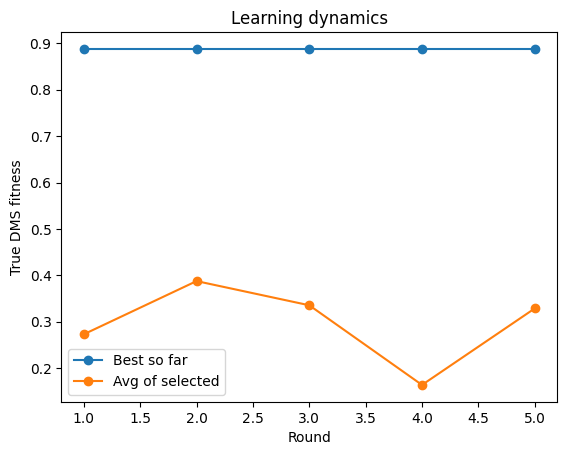

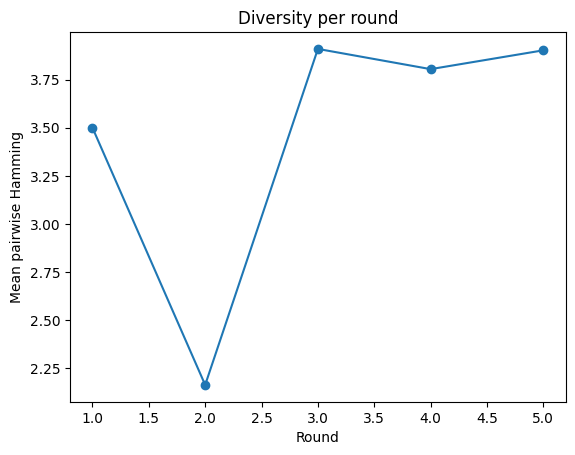

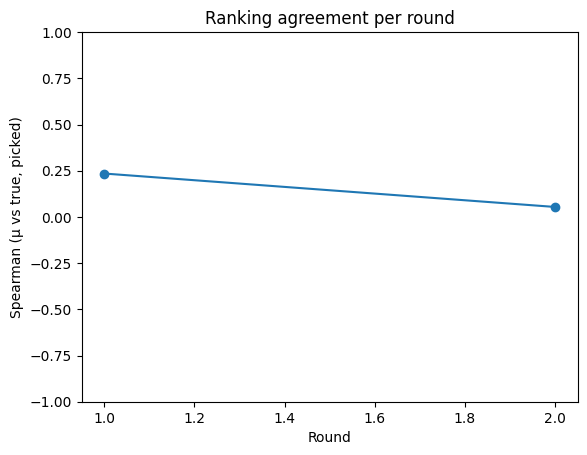

In [56]:
import matplotlib.pyplot as plt

# Learning curves
plt.figure()
plt.plot(summary_df["round"], summary_df["best_so_far"], marker="o", label="Best so far")
plt.plot(summary_df["round"], summary_df["avg_selected"], marker="o", label="Avg of selected")
plt.xlabel("Round"); plt.ylabel("True DMS fitness"); plt.title("Learning dynamics")
plt.legend(); plt.show()

# Diversity and Spearman
plt.figure()
plt.plot(summary_df["round"], summary_df["diversity_mean_hamming"], marker="o")
plt.xlabel("Round"); plt.ylabel("Mean pairwise Hamming"); plt.title("Diversity per round")
plt.show()

plt.figure()
plt.plot(summary_df["round"], summary_df["Spearman(μ,true)"], marker="o")
plt.xlabel("Round"); plt.ylabel("Spearman (μ vs true, picked)"); plt.ylim(-1,1)
plt.title("Ranking agreement per round"); plt.show()


Sanity :)

In [57]:
def sanity(embedder, surrogate, WT, labeled_data, props_df):
    print("MODE:", embedder.__dict__.get("_mode"), "| family:", MODEL_FAMILY, "| device:", ESM_DEVICE)
    test_seq = props_df.iloc[0]["seq"] if len(props_df) else labeled_data[0].seq
    E = embedder.encode([WT, test_seq])
    print("‖E(WT)-E(test)‖ =", float(np.linalg.norm(E[0]-E[1])))

    X = embedder.encode([x.seq for x in labeled_data])
    y = np.array([x.fitness for x in labeled_data], float)
    print("X std:", float(X.std()), " y std:", float(y.std()))

    if getattr(surrogate, "fitted", False):
        Z = StandardScaler().fit_transform(X.astype(np.float32))
        if hasattr(surrogate, "pca") and surrogate.pca is not None:
            Z = surrogate.pca.fit_transform(Z)
        print("Z std (post-transform):", float(Z.std()))
    else:
        print("Surrogate not fitted yet.")

sanity(embedder, surrogate, WT, labeled_data, props_df)

MODE: esm | family: esm1v | device: cuda


Embedding (esm1v) batches: 100%|██████████| 1/1 [00:00<00:00, 13.24it/s]


‖E(WT)-E(test)‖ = 0.337629497051239


Embedding (esm1v) batches: 100%|██████████| 14/14 [00:08<00:00,  1.63it/s]

X std: 0.8245397806167603  y std: 0.7747532042065632
Z std (post-transform): 6.075784206390381
